1 model review

2 hardware benchmark

3 Flash attention design and parallelization

4 GEMM design

5 Total benchmark

Constitution:

1 Prefill | Decode for every section

In [1]:
from helper import plot

## LlaMA 8B

Prefill Intensity: 384.47 FLOPs/byte

Decode Intensity: 19.46 FLOPs/byte

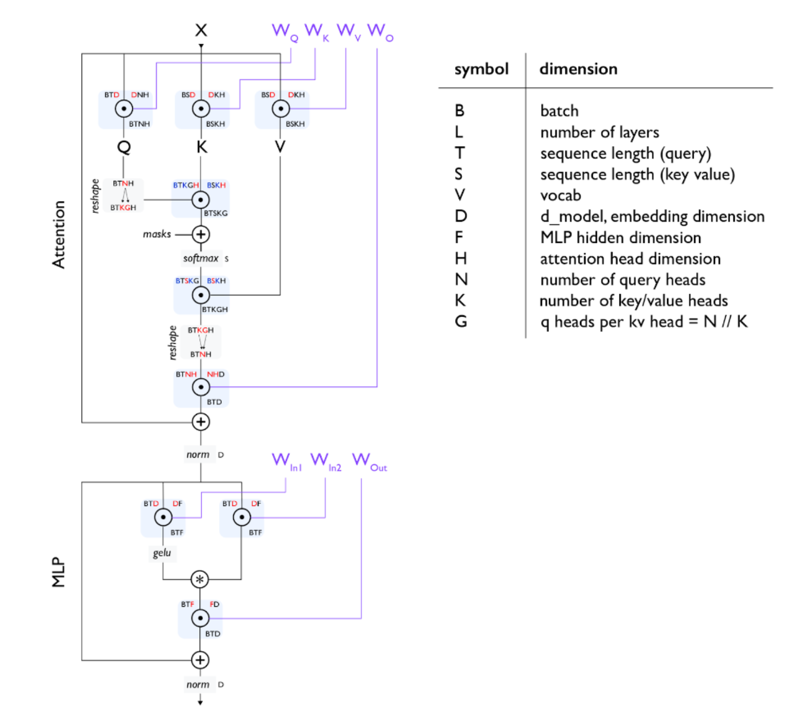

In [2]:
img = "img/LLM_tuning.png"
plot("img/LLM_tuning.png", 800)

B = 16 # Batch size
L = 32 # Layers
T = 2048 # Q length
S = 2048 # K length
D = 4096 # dimension
F = 14336 # FFN inter dim
N = 32 # Q head
K = 8 # KV head
H = 128 # d_head
G = N / K # Q heads / KV head
d_kv = 1024 # d_kv


# Attention
Q_shape = B * T * K * G * H # 16 x 2048 x 8 x 4 x 128
K_shape = B * S * K * H # 16 x 2048 x 8 x 128
V_shape = B * S * K * H # 16 x 2048 x 8 x 128



## Hardware


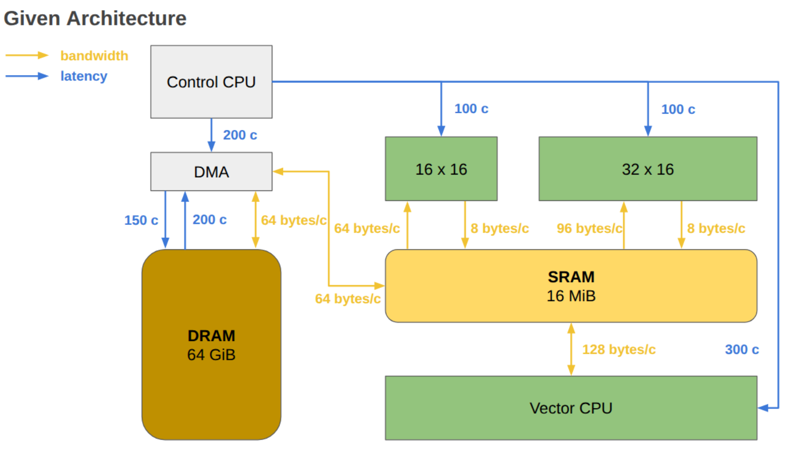

In [3]:
plot("img/architecture.png", 800)

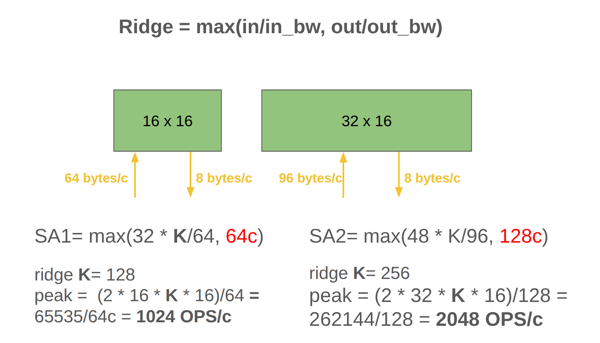

In [4]:
plot("img/SA_ridge.png", 600)

### Roofline analysis

Given the chip architecture and model hyperparameter, we plot the roofline:

chip ridge = 48.0


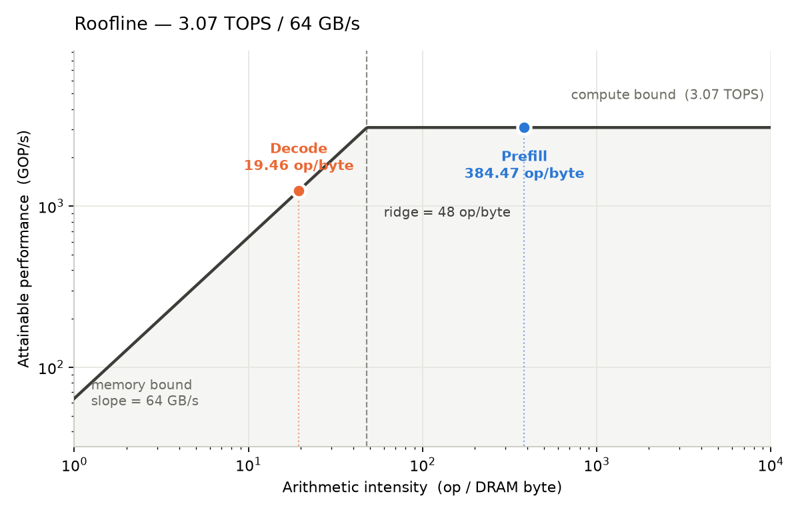

In [5]:
ridge_K_SA1 = 128
ridge_K_SA2 = 256
ops_SA1 = (2 * 16 * ridge_K_SA1 * 16) / 64
ops_SA2 = (2 * 32 * ridge_K_SA2 * 16) / 128
peak_ops = ops_SA1 + ops_SA2

peak_mem = 64 # DRAM -> SRAM

print(f"chip ridge = {peak_ops / peak_mem}")

plot(f"img/roofline.png", 800)